## Imports

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## Data overview

In [133]:
df = pd.read_csv('../dataset.csv')
print(df.shape)
df.head()

(1000, 14)


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [135]:
tempdf = df.copy()

tempdf.drop(columns=['ID', 'No_Pation'], inplace=True)
tempdf.describe().round(2)

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,53.53,5.12,68.94,8.28,4.86,2.35,1.20,2.61,1.85,29.58
std,8.80,2.94,59.98,2.53,1.30,1.40,0.66,1.12,3.66,4.96
min,20.00,0.50,6.00,0.90,0.00,0.30,0.20,0.30,0.10,19.00
25%,51.00,3.70,48.00,6.50,4.00,1.50,0.90,1.80,0.70,26.00
50%,55.00,4.60,60.00,8.00,4.80,2.00,1.10,2.50,0.90,30.00
75%,59.00,5.70,73.00,10.20,5.60,2.90,1.30,3.30,1.50,33.00
max,79.00,38.90,800.00,16.00,10.30,13.80,9.90,9.90,35.00,47.75


max values are crazy. they need to be hadled

In [136]:
overview = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique(),
    'sample_value': df.iloc[0]
})
overview

,dtype,non_null,null_count,null_pct,n_unique,sample_value
ID,int64,1000,0,0.0,800,502
No_Pation,int64,1000,0,0.0,961,17975
Gender,object,1000,0,0.0,3,F
AGE,int64,1000,0,0.0,50,50
Urea,float64,1000,0,0.0,110,4.7
Cr,int64,1000,0,0.0,113,46
HbA1c,float64,1000,0,0.0,111,4.9
Chol,float64,1000,0,0.0,77,4.2
TG,float64,1000,0,0.0,69,0.9
HDL,float64,1000,0,0.0,48,2.4


no nulls, that's great <br>
gender have 3 values, need to be handled. <br>
classes are 5 somehow, the description said it's going to be only 3 (Diabetic, Non-Diabetic, or Predict-Diabetic) <br>
also column names need to be normalized

In [137]:
df['Gender'].unique()

array(['F', 'M', 'f'], dtype=object)

In [138]:
df['CLASS'].unique()

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

ok, just some white spaces need to be cleaned

In [139]:
dupes = df.duplicated().sum()
print(dupes)

0


no duplicates, interesting.

## Class analysis

In [140]:
df['CLASS'] = df['CLASS'].str.strip()
print('CLASS value counts:')
print(df['CLASS'].value_counts())

CLASS value counts:
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


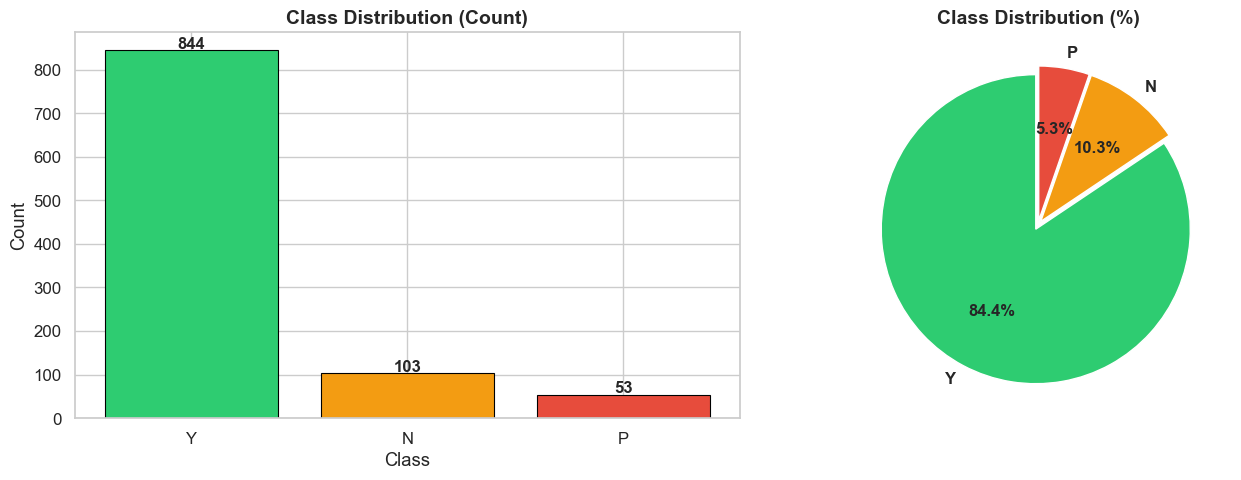

Class proportions:
CLASS
Y    84.4
N    10.3
P     5.3
Name: proportion, dtype: float64


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
class_counts = df['CLASS'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.8)
for i, (idx, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.03]*len(class_counts),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('Class proportions:')
print((df['CLASS'].value_counts(normalize=True) * 100).round(2))

diabolical. <br>
classes are inconsistent at all, and the Y class is crazy dominant, while the P class is so low in count like damn.

## Gender Analysis

In [145]:
df['Gender'] = df['Gender'].str.strip().str.upper()
print(df['Gender'].value_counts())

Gender
M    565
F    435
Name: count, dtype: int64


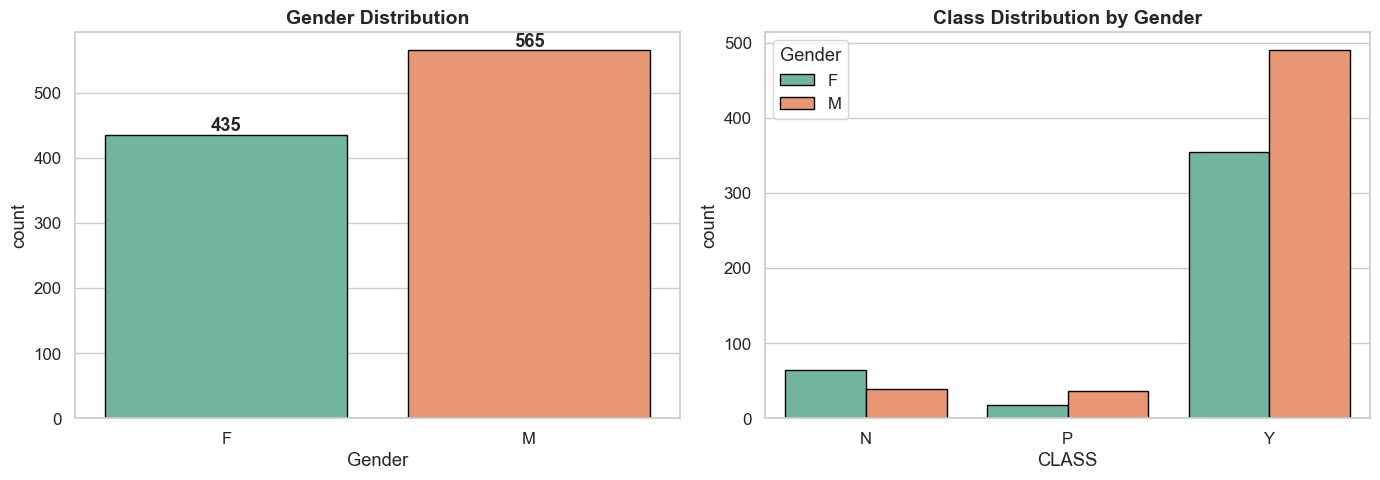


Gender vs CLASS crosstab:
CLASS     N   P    Y   All
Gender                    
F        64  17  354   435
M        39  36  490   565
All     103  53  844  1000


In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution
sns.countplot(data=df, x='Gender', ax=axes[0], palette='Set2', edgecolor='black')
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Gender vs CLASS
sns.countplot(data=df, x='CLASS', hue='Gender', ax=axes[1], palette='Set2', edgecolor='black')
axes[1].set_title('Class Distribution by Gender', fontsize=14, fontweight='bold')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

print('\nGender vs CLASS crosstab:')
print(pd.crosstab(df['Gender'], df['CLASS'], margins=True))

## Age analysis

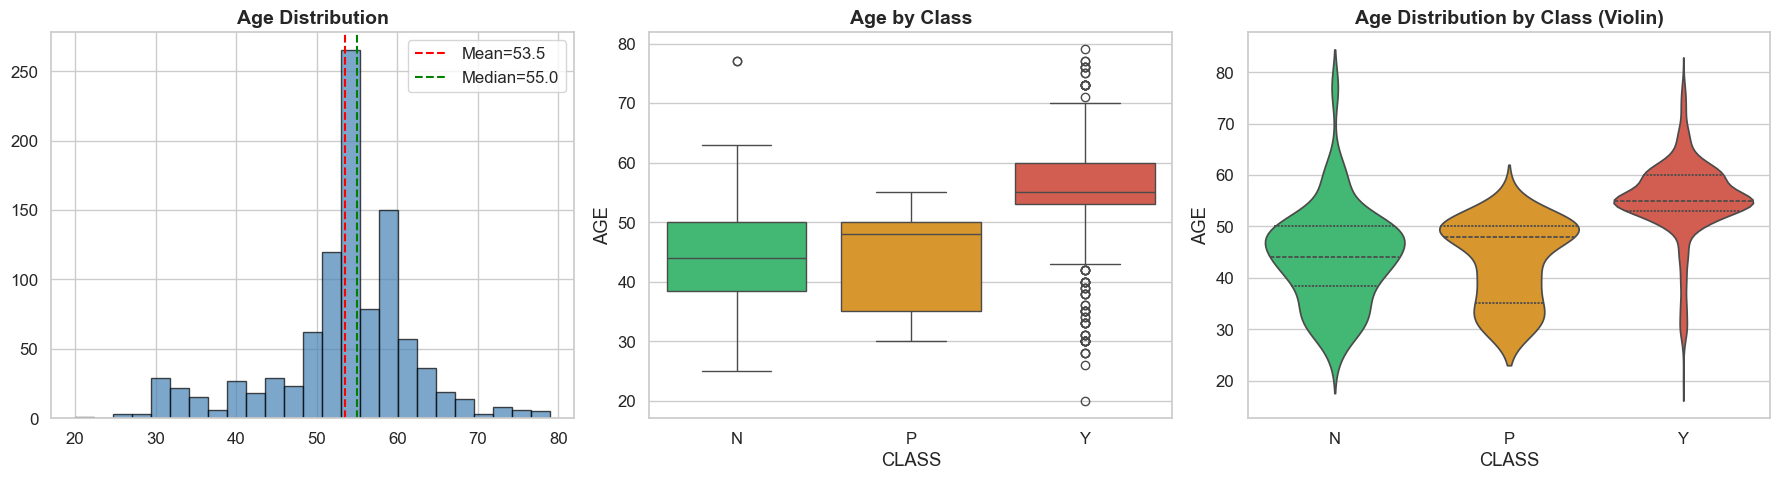

Age statistics by CLASS:
       count   mean   std   min   25%   50%   75%   max
CLASS                                                  
N      103.0  44.23  9.42  25.0  38.5  44.0  50.0  77.0
P       53.0  43.28  7.76  30.0  35.0  48.0  50.0  55.0
Y      844.0  55.31  7.55  20.0  53.0  55.0  60.0  79.0


In [146]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['AGE'], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['AGE'].mean(), color='red', linestyle='--', label=f'Mean={df["AGE"].mean():.1f}')
axes[0].axvline(df['AGE'].median(), color='green', linestyle='--', label=f'Median={df["AGE"].median():.1f}')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].legend()

# Box plot by CLASS
sns.boxplot(data=df, x='CLASS', y='AGE', ax=axes[1], palette=colors)
axes[1].set_title('Age by Class', fontsize=14, fontweight='bold')

# Violin plot by CLASS
sns.violinplot(data=df, x='CLASS', y='AGE', ax=axes[2], palette=colors, inner='quartile')
axes[2].set_title('Age Distribution by Class (Violin)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('Age statistics by CLASS:')
print(df.groupby('CLASS')['AGE'].describe().round(2))

## Numerical columns analysis

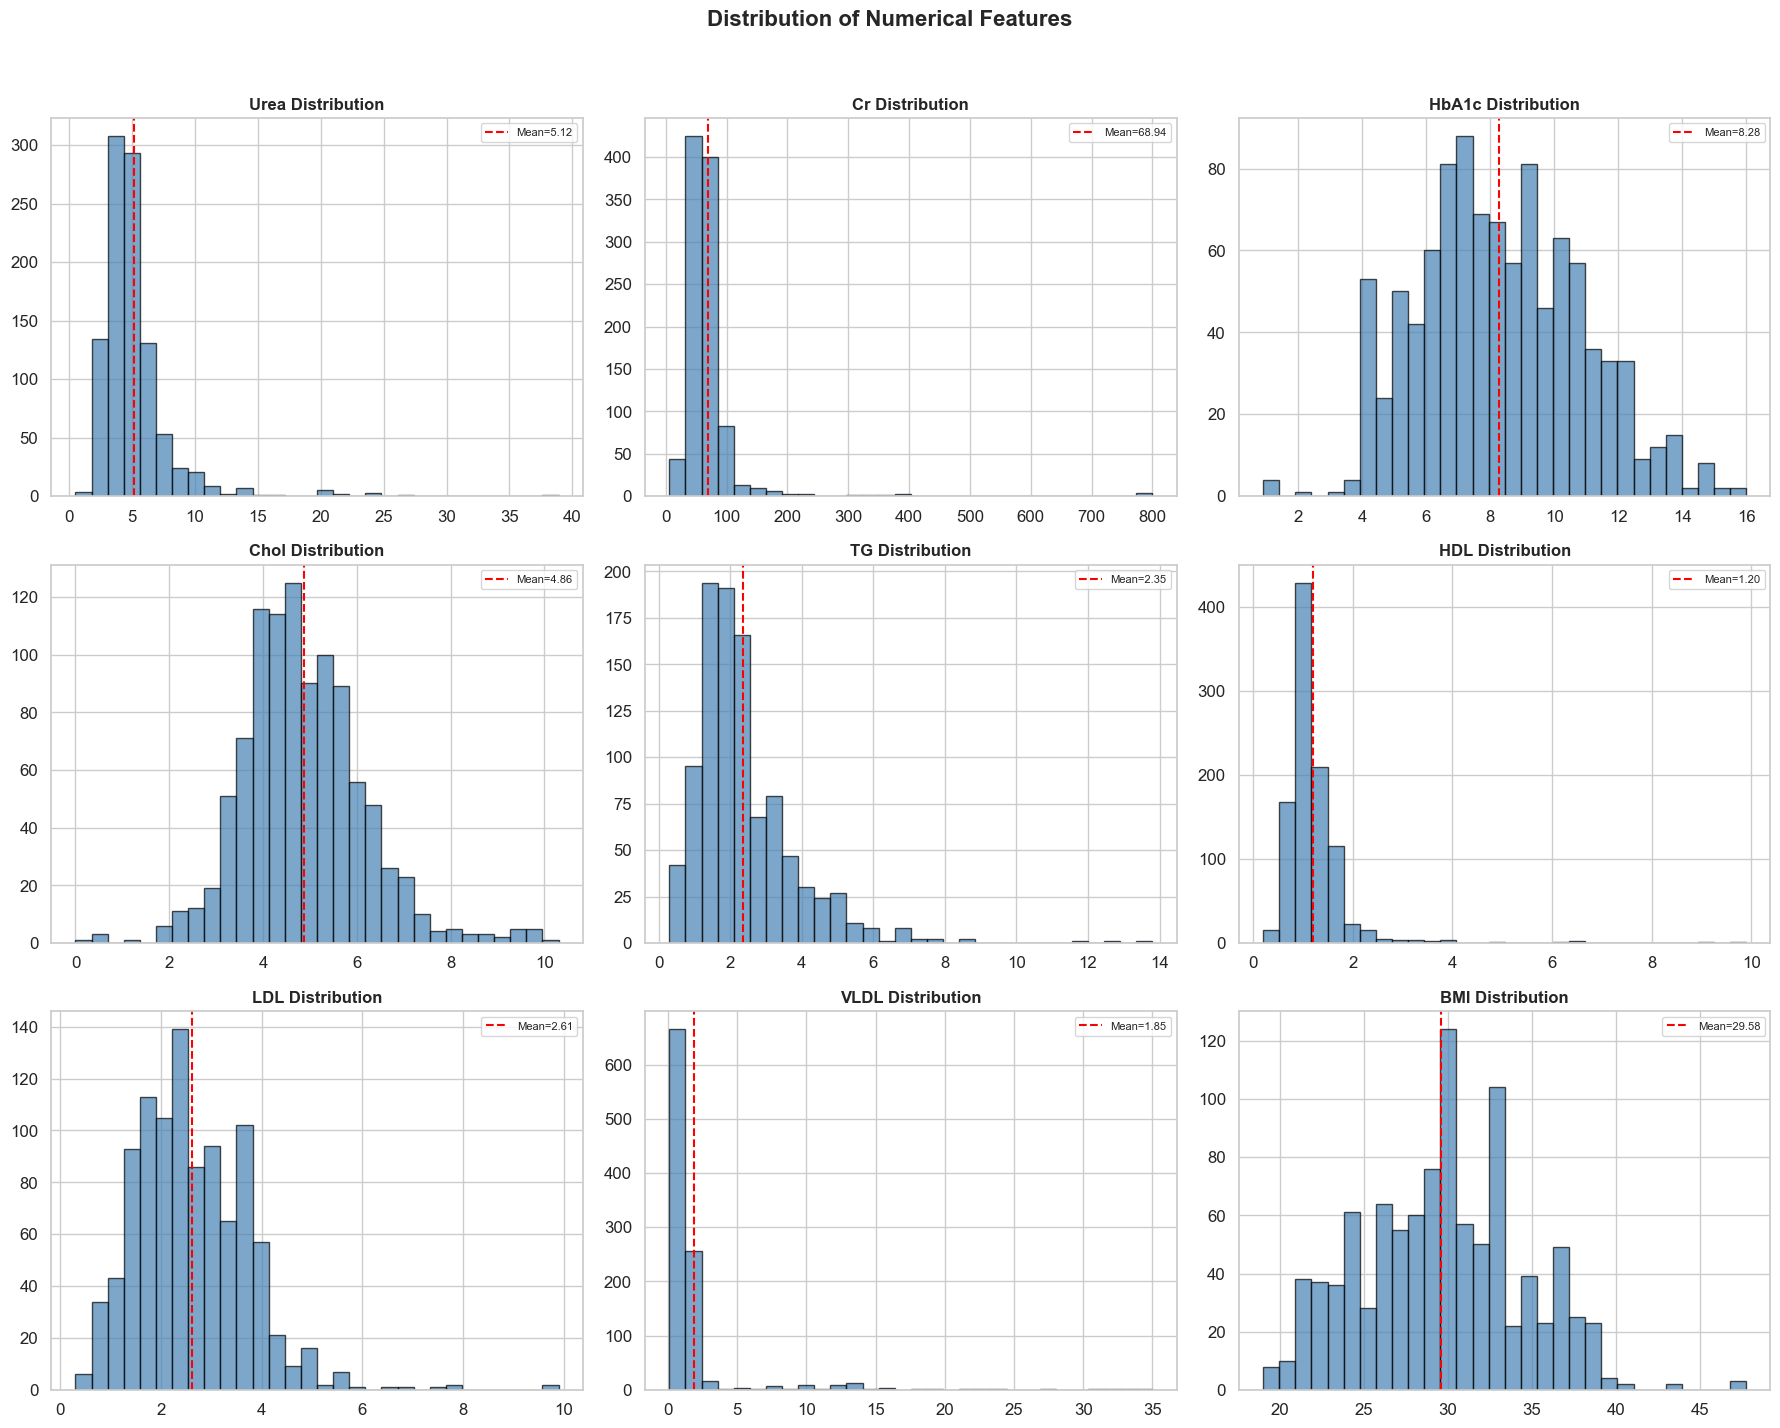

In [147]:
num_cols = ['Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.2f}')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

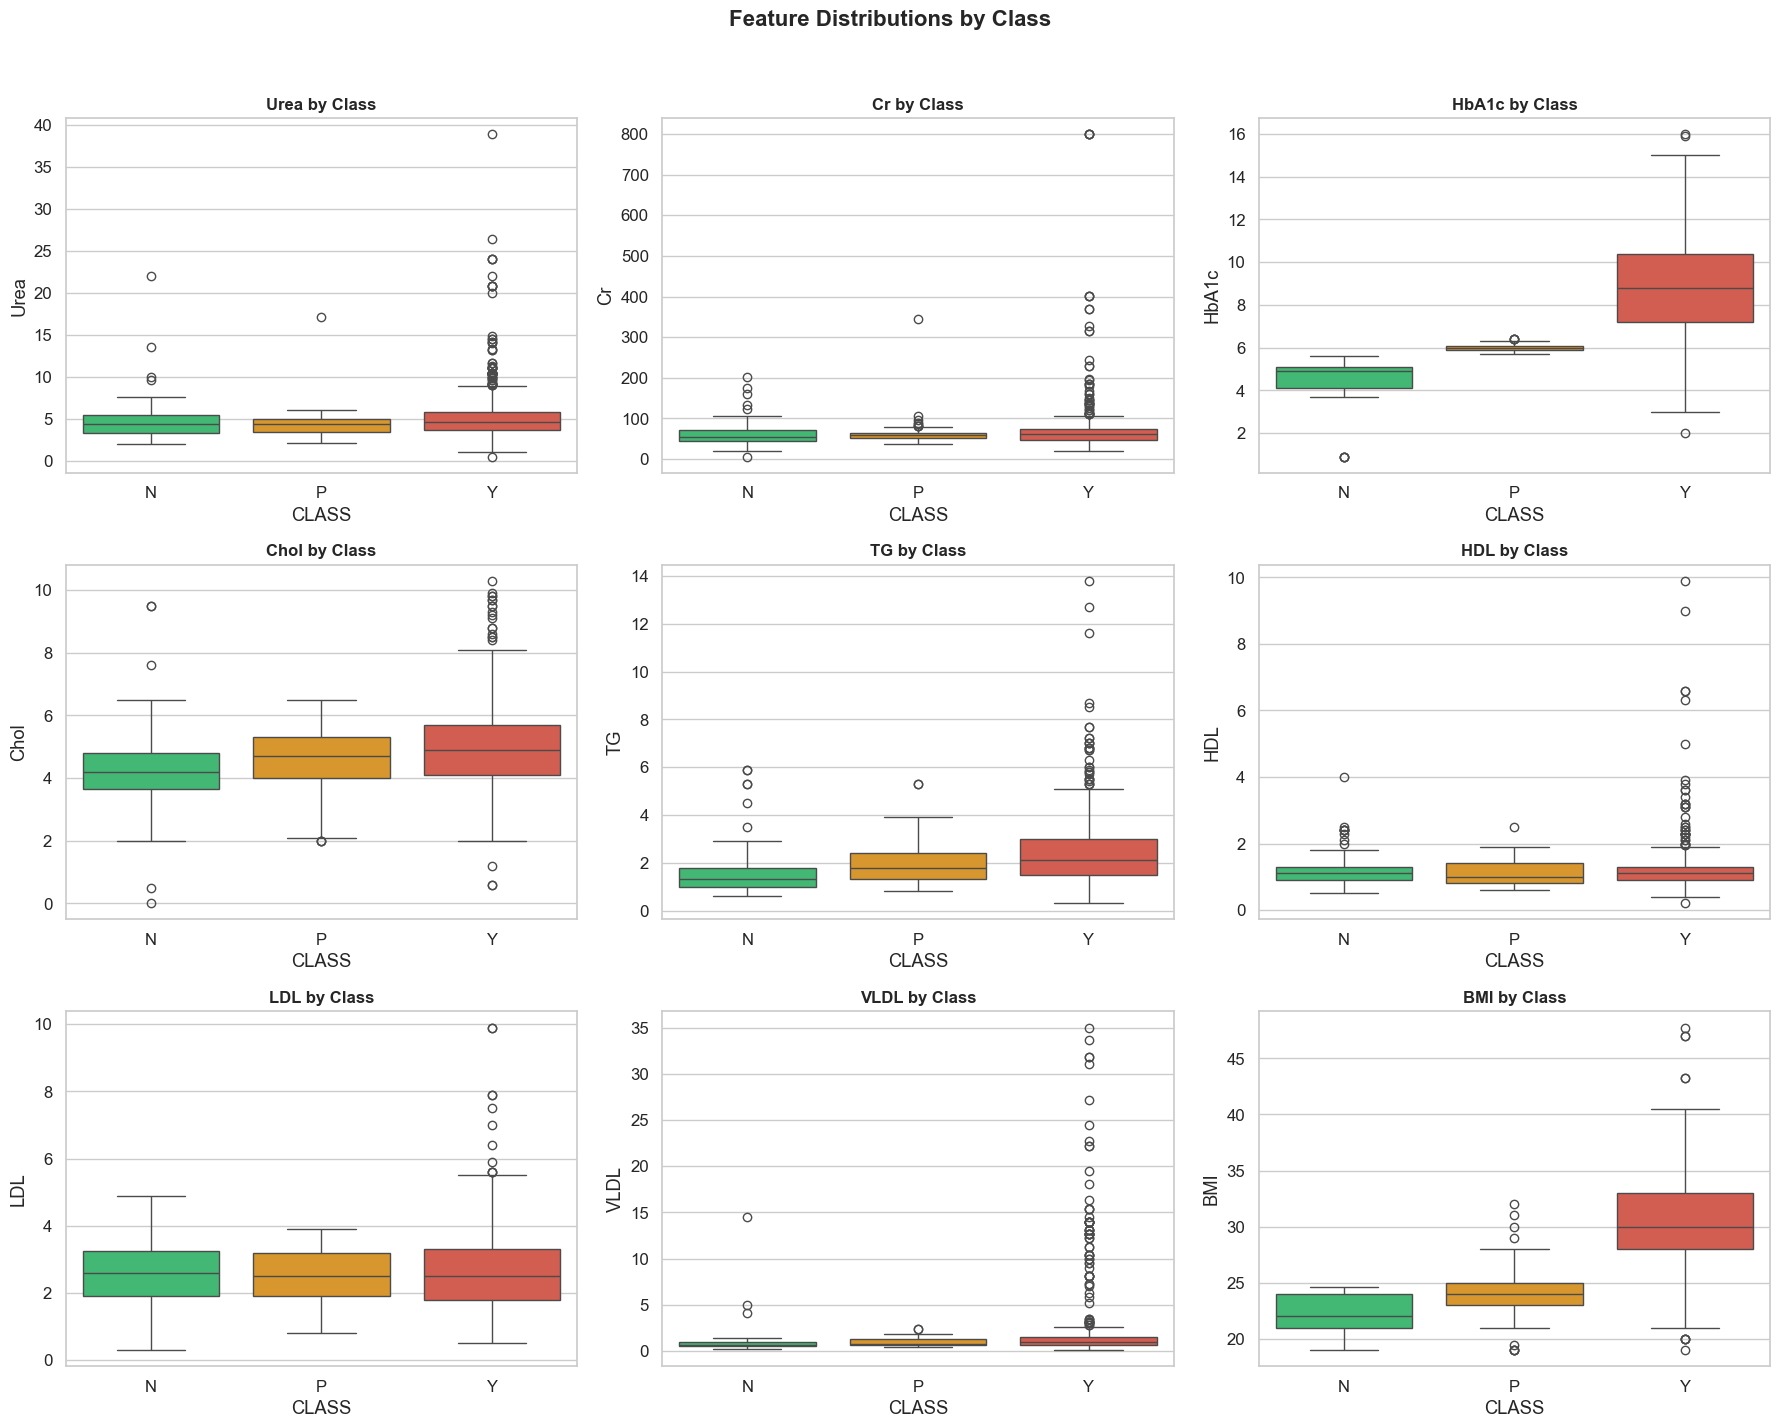

In [148]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='CLASS', y=col, ax=axes[i], palette=colors, order=['N', 'P', 'Y'])
    axes[i].set_title(f'{col} by Class', fontsize=12, fontweight='bold')

plt.suptitle('Feature Distributions by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [150]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers, lower, upper

outlier_summary = []
for col in ['AGE'] + num_cols:
    count, lower, upper = count_outliers_iqr(df[col])
    outlier_summary.append({
        'Feature': col,
        'Outlier_Count': count,
        'Outlier_Pct': round(count / len(df) * 100, 2),
        'Lower_Bound': round(lower, 2),
        'Upper_Bound': round(upper, 2),
        'Min': df[col].min(),
        'Max': df[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary)
print('Outlier Summary (IQR Method):')
outlier_df

Outlier Summary (IQR Method):


,Feature,Outlier_Count,Outlier_Pct,Lower_Bound,Upper_Bound,Min,Max
0,AGE,98,9.8,39.00,71.00,20.0,79.00
1,Urea,65,6.5,0.70,8.70,0.5,38.90
2,Cr,52,5.2,10.50,110.50,6.0,800.00
3,HbA1c,6,0.6,0.95,15.75,0.9,16.00
4,Chol,27,2.7,1.60,8.00,0.0,10.30
5,TG,55,5.5,-0.60,5.00,0.3,13.80
6,HDL,50,5.0,0.30,1.90,0.2,9.90
7,LDL,11,1.1,-0.45,5.55,0.3,9.90
8,VLDL,74,7.4,-0.50,2.70,0.1,35.00
9,BMI,3,0.3,15.50,43.50,19.0,47.75


BMI and Hba1c has the least outliers <br>
somehow Chol min is 0, like a person with no cholesterol. that's crazy. <br>

## Correlation analysis

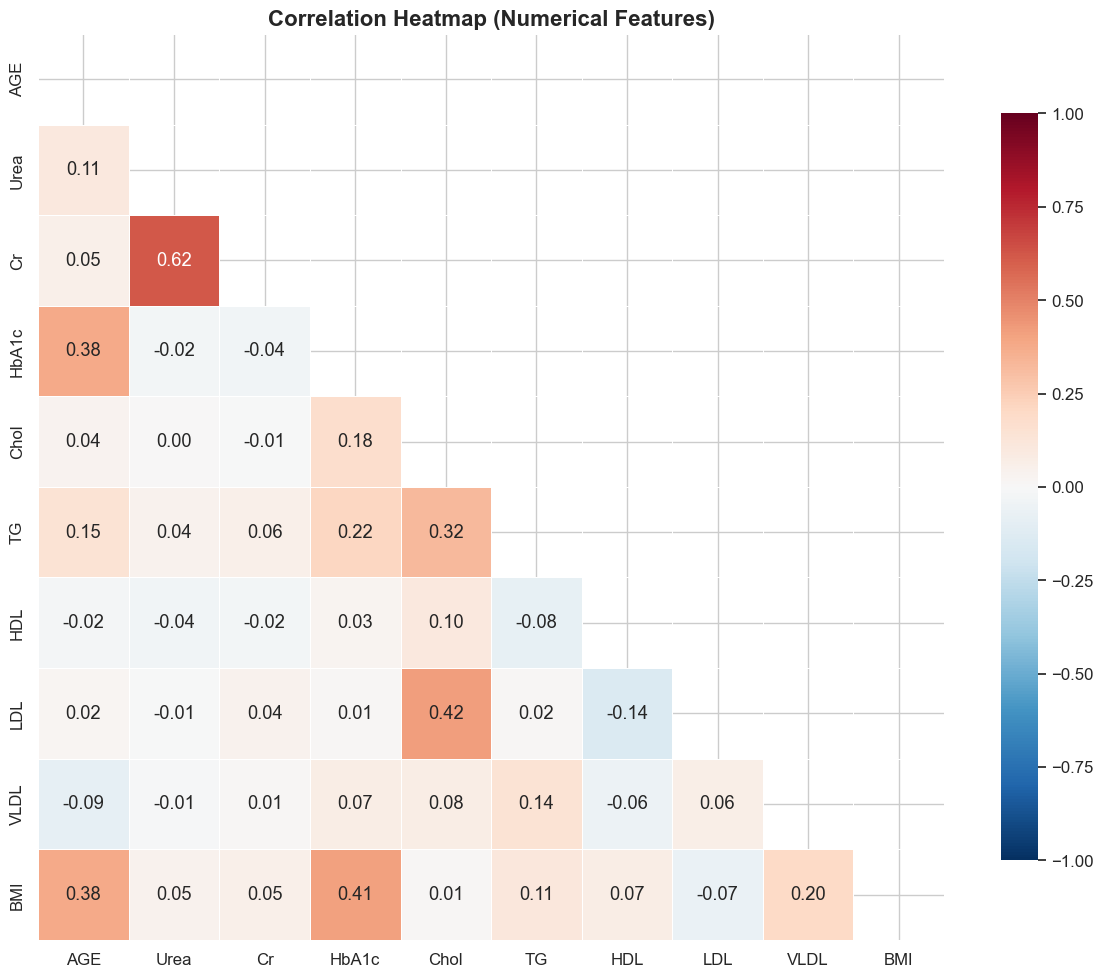

In [149]:
corr_cols = ['AGE'] + num_cols
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numerical Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()